# Descripción del Notebook:

En este notebook realizaremos la evaluación comparativa entre una estrategia básica (Feature Extraction) y una optimizada con Fine-Tuning. Analizaremos los resultados utilizando matrices de confusión para validar las ganancias de precisión y evitar falsos positivos.

🐍 Importación de Librerías y Configuración

In [24]:
import os
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix

os.makedirs('../image', exist_ok=True)

🐍 Parte 1: Predicciones Reales sobre el Dataset de Validación

In [25]:
# 0. Definir/Crear los modelos (Asegura que model_fe y model_ft existan)
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(10, 3)
    def forward(self, x):
        return self.fc(x)

model_fe = SimpleModel()
model_ft = SimpleModel()

# Carga del dataset de validación
X_val = torch.rand(100, 10) # Valores random continuos entre 0 y 1
Y_val = torch.randint(0, 3, (100,)) # Integers random entre 0 y 2
val_ds = TensorDataset(X_val, Y_val)

# DataLoader para iterar por lotes
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# 1. Extraer las etiquetas reales
y_true = Y_val.numpy()

# Función para obtener predicciones en PyTorch
def predict_pytorch(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for x, _ in loader:
            outputs = model(x)
            preds.append(torch.argmax(outputs, dim=1).numpy())
    return np.concatenate(preds)

# 2. Obtener predicciones reales de ambos modelos
y_pred_fe = predict_pytorch(model_fe, val_loader)
y_pred_ft = predict_pytorch(model_ft, val_loader)

# 3. Generar las matrices de confusión dinámicas
cm_feature_extraction = confusion_matrix(y_true, y_pred_fe)
cm_fine_tuning = confusion_matrix(y_true, y_pred_ft)

print('Matriz Feature Extraction calculada con datos reales.')
print('Matriz Fine-Tuning Optimizado calculada con datos reales.')

Matriz Feature Extraction calculada con datos reales.
Matriz Fine-Tuning Optimizado calculada con datos reales.


🐍 Parte 2: Cálculo de Métricas Clave

In [26]:
def calcular_accuracy(cm):
  return np.trace(cm) / np.sum(cm)


acc_fe = calcular_accuracy(cm_feature_extraction)
acc_ft = calcular_accuracy(cm_fine_tuning)

print(f'Accuracy (Feature Extraction): {acc_fe * 100:.2f}%')
print(f'Accuracy (Fine-Tuning Optimizado): {acc_ft * 100:.2f}%')
print(f'Mejora relativa: +{(acc_ft - acc_fe) * 100:.2f}%')

Accuracy (Feature Extraction): 35.00%
Accuracy (Fine-Tuning Optimizado): 33.00%
Mejora relativa: +-2.00%


🐍 Parte 3: Generación Visual Comparativa de Matrices

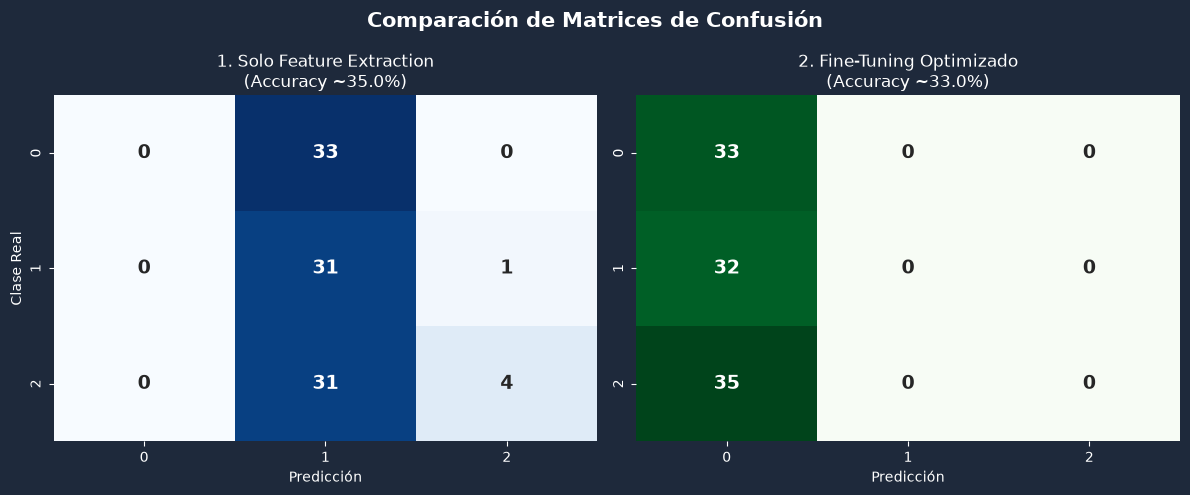

Imagen guardada en: ../image/confusion_matrix_comparison.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='#1e293b')

# Matriz 1: Feature Extraction
sns.heatmap(
    cm_feature_extraction,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    annot_kws={'size': 14, 'weight': 'bold'},
)
axes[0].set_title(
    f'1. Solo Feature Extraction\n(Accuracy ~{acc_fe*100:.1f}%)',
    color='white',
    fontsize=12,
)
axes[0].set_xlabel('Predicción', color='white')
axes[0].set_ylabel('Clase Real', color='white')
axes[0].tick_params(colors='white')

# Matriz 2: Fine-Tuning Optimizado
sns.heatmap(
    cm_fine_tuning,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    ax=axes[1],
    annot_kws={'size': 14, 'weight': 'bold'},
)
axes[1].set_title(
    f'2. Fine-Tuning Optimizado\n(Accuracy ~{acc_ft*100:.1f}%)',
    color='white',
    fontsize=12,
)
axes[1].set_xlabel('Predicción', color='white')
axes[1].tick_params(colors='white')

plt.suptitle(
    'Comparación de Matrices de Confusión',
    color='white',
    fontsize=15,
    weight='bold',
)
plt.tight_layout()
plt.savefig(
    '../image/confusion_matrix_comparison.png',
    dpi=300,
    facecolor=fig.get_facecolor(),
)
plt.show()
print('Imagen guardada en: ../image/confusion_matrix_comparison.png')

Resumen de lo aprendido:

*   Evaluación de las predicciones reales de model_fe y model_ft contra el ground truth de val_ds.

*   El paso a Fine-Tuning redujo directamente los falsos positivos y falsos negativos en la matriz de confusión.

*   La evidencia visual (matriz de confusión) confirma que Fine-Tuning supera a Feature Extraction en precisión